In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data_path = "../Data/creditcard.csv"
df = pd.read_csv(data_path)

In [3]:
print("Dataset shape:", df.shape)

Dataset shape: (284807, 31)


In [4]:
print("\nFirst few rows:")
print(df.head())


First few rows:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26    

In [5]:
print("\nColumn names:")
print(df.columns)


Column names:
Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')


In [6]:
print("\nDataset info:")
print(df.info())


Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21   

In [7]:
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [8]:
print(df.isnull().sum().sum())

0


In [9]:
print("\nClass distribution:")
print(df["Class"].value_counts())


Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64


In [10]:
print("\nClass distribution percentage:")
print(df["Class"].value_counts(normalize=True) * 100)


Class distribution percentage:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


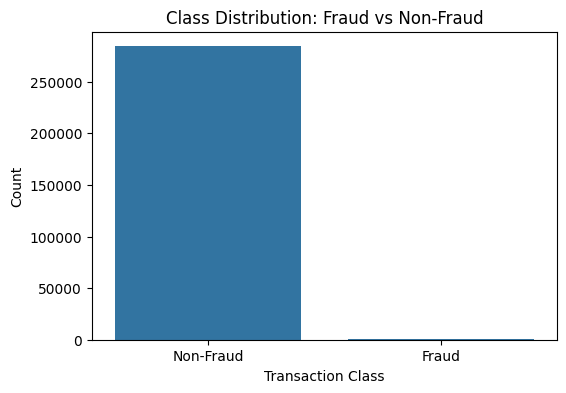

In [11]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Class", data=df)

plt.title("Class Distribution: Fraud vs Non-Fraud")
plt.xlabel("Transaction Class")
plt.ylabel("Count")
plt.xticks([0, 1], ["Non-Fraud", "Fraud"])

plt.show()

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [13]:
# Features
X = df.drop("Class", axis=1)

# Target
y = df["Class"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (284807, 30)
Target Shape: (284807,)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (227845, 30)
Testing Shape: (56962, 30)


In [15]:
scaler = StandardScaler()

X_train[["Time", "Amount"]] = scaler.fit_transform(
    X_train[["Time", "Amount"]]
)

X_test[["Time", "Amount"]] = scaler.transform(
    X_test[["Time", "Amount"]]
)

print("Scaling Completed")

Scaling Completed


In [16]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [17]:
y_pred = model.predict(X_test)

In [18]:
print("Accuracy :", accuracy_score(y_test, y_pred))

print("Precision:", precision_score(y_test, y_pred))

print("Recall   :", recall_score(y_test, y_pred))

print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.9991573329588147
Precision: 0.8289473684210527
Recall   : 0.6428571428571429
F1 Score : 0.7241379310344828


In [19]:
print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



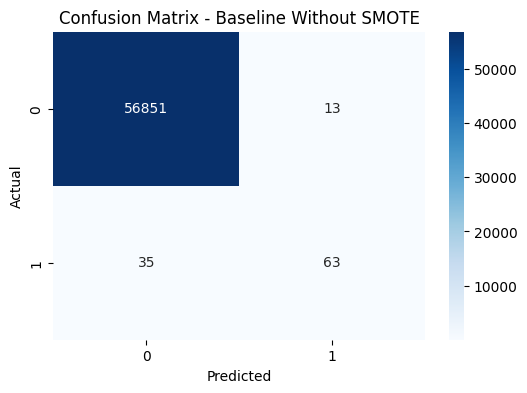

In [20]:
plt.figure(figsize=(6,4))

sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - Baseline Without SMOTE")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# 🚨 Baseline Model Analysis (Without SMOTE)

---

# 📌 Dataset Nature

The credit card fraud dataset is **highly imbalanced**.

| Class | Meaning                | Percentage |
| ----- | ---------------------- | ---------- |
| 0     | Non-Fraud Transactions | ~99.83%    |
| 1     | Fraud Transactions     | ~0.17%     |

This means the model sees very few fraud examples during training.

Because of this imbalance, **Accuracy alone is NOT a reliable metric** for evaluating fraud detection systems.

A model can predict almost every transaction as **Non-Fraud** and still achieve extremely high accuracy.

Therefore, metrics like:

* 🎯 Precision
* 🔍 Recall
* ⚖️ F1 Score

become much more important.

---

# 🧩 Confusion Matrix Terminology

| Term                   | Meaning                                              |
| ---------------------- | ---------------------------------------------------- |
| ✅ True Positive (TP)   | Fraud transaction correctly detected as fraud        |
| ✅ True Negative (TN)   | Genuine transaction correctly detected as non-fraud  |
| ⚠️ False Positive (FP) | Genuine transaction incorrectly flagged as fraud     |
| ❌ False Negative (FN)  | Fraud transaction incorrectly predicted as non-fraud |

---

# 📊 Evaluation Metrics

## 🎯 Accuracy

Accuracy = {TP + TN}/{TP + TN + FP + FN}

### Meaning

Measures the overall percentage of correct predictions.

### ⚠️ Problem in Imbalanced Datasets

Accuracy can become misleading because the majority class dominates the dataset.

Example:

If the model predicts almost everything as non-fraud, it may still achieve ~99% accuracy while failing to detect fraud properly.

---

## 🎯 Precision

Precision = {TP}/{TP + FP}

### Meaning

Out of all transactions predicted as fraud, how many were actually fraud?

### ✅ High Precision Means

* Fewer false fraud alerts
* More trustworthy fraud predictions

---

## 🔍 Recall

Recall = {TP}/{TP + FN}

### Meaning

Out of all actual fraud transactions, how many were successfully detected?

### 🚨 Why Recall is Extremely Important

In fraud detection:

Missing fraud transactions can directly lead to financial losses.

Therefore, Recall is often one of the MOST IMPORTANT metrics in fraud detection systems.

---

## ⚖️ F1 Score

F1 = 2 * {Precision * Recall}/{Precision + Recall}

### Meaning

F1 Score is the harmonic mean of Precision and Recall.

It provides a balanced evaluation when dealing with imbalanced datasets.

---

# 📈 Baseline Model Results (Without SMOTE)

| Metric       | Score  |
| ------------ | ------ |
| 🎯 Accuracy  | 99.91% |
| 🎯 Precision | 82.89% |
| 🔍 Recall    | 64.29% |
| ⚖️ F1 Score  | 72.41% |

---

# 🧠 Interpretation of Results

## 🎯 Accuracy = 99.91%

The model achieves extremely high accuracy.

However, this does NOT necessarily mean the model is excellent.

Since the dataset is heavily imbalanced, the model benefits greatly from correctly predicting the majority non-fraud class.

---

## 🎯 Precision = 82.89%

When the model predicts a transaction as fraud, it is correct around 83% of the time.

### ✅ Insight

The model generates relatively few false fraud alerts.

---

## 🔍 Recall = 64.29%

The model successfully detects only around 64% of actual fraud transactions.

### 🚨 Critical Insight

Approximately **36% of fraud transactions are still being missed**.

These missed fraud cases are extremely important in real-world banking systems because undetected fraud can lead to financial losses.

---

## ⚖️ F1 Score = 72.41%

The model shows a reasonable balance between Precision and Recall.

However, there is still significant room for improvement in fraud detection capability.

---

# 🚀 Core Insight of This Project

This baseline model intentionally demonstrates the limitation of training directly on highly imbalanced data.

The next phase of this project will apply:

# 🔥 SMOTE (Synthetic Minority Oversampling Technique)

to improve the model’s ability to detect fraud transactions.

---

# 🎯 Expected Improvements After SMOTE

| Expected Change                      | Impact                           |
| ------------------------------------ | -------------------------------- |
| 🔍 Higher Recall                     | More frauds detected             |
| ❌ Lower False Negatives              | Fewer frauds missed              |
| ⚖️ Better Fraud Detection Capability | Improved minority class learning |
| 🎯 Slight Accuracy Reduction         | Acceptable tradeoff              |

---

# 🏁 Final Understanding

This baseline notebook serves as the reference point for comparing:

# ✅ Without SMOTE vs 🔥 With SMOTE

to analyze how imbalance handling techniques affect fraud detection performance in Machine Learning systems.
